# Notebook 3 — Modélisation & Évaluation
**Projet IndabaX 2026 — Cameroun** | Prédiction du VRI — horizon **t+7 jours**

Prérequis : exécuter `01_EDA.ipynb` puis `02_FeatureEngineering.ipynb`

**Stratégie** : Un seul modèle global entraîné sur **toutes les 42 villes** simultanément.
`city_enc` et `city_vri_mean/std` permettent au modèle d'apprendre les spécificités de chaque ville.

Pipeline :
1. Chargement → 2. Split t+7 → 3. Baselines → 4. Random Forest → 5. XGBoost →
6. LightGBM → 7. LightGBM Optimisé → 8. Comparaison → 9. Résidus →
10. Importance features → 11. Performances par ville → 12. Prédictions vs réalité →
13. Classification du risque → 14. Courbes ROC → 15. Tableau final → 16. Export


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pickle, joblib, json as _json, os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import ParameterGrid
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import skew
import xgboost as xgb
import lightgbm as lgb

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

RANDOM_STATE = 42
TEST_YEAR    = 2025
HORIZON      = 7          # horizon unique : t+7 jours
SEUIL_ELEVE  = 0.66       # seuil de classification risque élevé
RESULTS      = []         # liste pour stocker tous les résultats

print(f'Imports OK  |  Horizon unique : t+{HORIZON} jours  |  Modèle : global (42 villes)')


Imports OK  |  Horizon unique : t+7 jours  |  Modèle : global (42 villes)


## 1. Chargement du contexte

In [2]:
df_feat      = pickle.load(open('../outputs/df_feat.pkl',           'rb'))
FEATURE_COLS = pickle.load(open('../outputs/feature_cols_list.pkl', 'rb'))
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_feat.columns]

# Villes de référence pour les visualisations
villes_ref = [v for v in ['Maroua','Douala','Ngaoundere','Yaounde','Bafoussam']
              if v in df_feat['city'].values][:4]

print(f'df_feat      : {df_feat.shape}')
print(f'Features     : {len(FEATURE_COLS)}')
print(f'Villes       : {df_feat["city"].nunique()} | Régions : {df_feat["region"].nunique()}')
print(f'Villes réf   : {villes_ref}')
print(f'Colonnes VRI : {[c for c in df_feat.columns if "VRI" in c or "target" in c]}')


df_feat      : (87240, 78)
Features     : 32
Villes       : 40 | Régions : 10
Villes réf   : ['Maroua', 'Douala', 'Ngaoundere', 'Yaounde']
Colonnes VRI : ['VRI', 'VRI_lag_1', 'VRI_lag_2', 'VRI_lag_3', 'VRI_lag_7', 'VRI_lag_10', 'VRI_lag_14', 'VRI_lag_21', 'VRI_lag_30', 'VRI_roll7_mean', 'VRI_roll7_std', 'VRI_roll7_max', 'VRI_roll14_mean', 'VRI_roll14_std', 'VRI_roll14_max', 'VRI_roll30_mean', 'VRI_roll30_std', 'VRI_roll30_max', 'VRI_clim_month', 'VRI_anomaly', 'target_t7', 'VRI_v2', 'VRI_v2_lag_1', 'VRI_v2_lag_7', 'VRI_v2_lag_14', 'VRI_v2_roll7_mean']


## 2. Split temporel — horizon t+7
Split chronologique strict sur toutes les villes :
- **Train** : 2020–2023 (toutes villes)
- **Validation** : 2024 (toutes villes)
- **Test** : 2025 (toutes villes)

Le modèle est entraîné **une seule fois** sur l'ensemble des villes. `city_enc` et
`city_vri_mean/std` permettent d'apprendre les spécificités de chaque ville.


In [3]:
def make_split(df, horizon=HORIZON):
    target = f'target_t{horizon}'
    req    = FEATURE_COLS + [target, 'city', 'time', 'region', 'year']
    req    = [c for c in req if c in df.columns]
    dm     = df[req].dropna().reset_index(drop=True)
    train  = dm[dm['year'] <= 2023].reset_index(drop=True)
    val    = dm[dm['year'] == 2024].reset_index(drop=True)
    test   = dm[dm['year'] == TEST_YEAR].reset_index(drop=True)
    return (train[FEATURE_COLS], train[target],
            val[FEATURE_COLS],   val[target],
            test[FEATURE_COLS],  test[target],
            train, val, test)

X_tr, y_tr, X_val, y_val, X_te, y_te, tr, v, te = make_split(df_feat, HORIZON)

print(f'Split t+{HORIZON} — modèle global (toutes villes) :')
print(f'  Train      : {len(X_tr):>7,} obs | {tr["time"].min().date()} → {tr["time"].max().date()}')
print(f'  Validation : {len(X_val):>7,} obs | {v["time"].min().date()} → {v["time"].max().date()}')
print(f'  Test       : {len(X_te):>7,} obs | {te["time"].min().date()} → {te["time"].max().date()}')
print(f'  Villes train : {tr["city"].nunique()} | val : {v["city"].nunique()} | test : {te["city"].nunique()}')

# Anti-leakage
assert tr['time'].max() < v['time'].min(), 'LEAKAGE train/val !'
assert v['time'].max()  < te['time'].min(), 'LEAKAGE val/test !'
print('Anti-leakage : OK ✓')

# Baseline persistance t+7 : VRI d'il y a 7 jours comme prédiction naïve
naive_val  = X_val['VRI_lag_7'].values
naive_test = X_te['VRI_lag_7'].values


Split t+7 — modèle global (toutes villes) :
  Train      :  57,240 obs | 2020-01-31 → 2023-12-31
  Validation :  14,640 obs | 2024-01-01 → 2024-12-31
  Test       :  13,880 obs | 2025-01-01 → 2025-12-13
  Villes train : 40 | val : 40 | test : 40
Anti-leakage : OK ✓


## 3. Fonctions de métriques
- **MAE** : erreur absolue moyenne
- **RMSE** : pénalise davantage les grosses erreurs
- **Skill Score** : amélioration relative vs persistance naïve (>0 = utile, 1 = parfait)


In [4]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def skill_score(y_true, y_pred, y_naive):
    mae_model = mean_absolute_error(y_true, y_pred)
    mae_naive = mean_absolute_error(y_true, y_naive)
    return round(1 - mae_model / (mae_naive + 1e-10), 4)

def evaluate(y_true, y_pred, y_naive, label=''):
    mae = mean_absolute_error(y_true, y_pred)
    rms = rmse(y_true, y_pred)
    ss  = skill_score(y_true, y_pred, y_naive)
    if label:
        print(f'{label:<45} MAE={mae:.4f}  RMSE={rms:.4f}  Skill={ss:.4f}')
    return {'Modele': label, 'MAE': round(mae,4),
            'RMSE': round(rms,4), 'Skill': ss}


## 4. Baselines
Deux baselines pour fixer le plancher de performance :
- **Persistance t+7** : prédit le VRI d'aujourd'hui pour dans 7 jours
- **Dummy (mean)** : prédit toujours la moyenne globale du train


In [5]:
# ── Baseline Persistance ──
for split, ytrue, ypred, naive in [
    ('Val',  y_val, naive_val,  naive_val),
    ('Test', y_te,  naive_test, naive_test),
]:
    r = evaluate(ytrue, ypred, naive, f'Baseline persistance t+{HORIZON} [{split}]')
    r['Split'] = split; RESULTS.append(r)

# ── Dummy (mean) ──
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_tr, y_tr)
pred_dummy_val  = dummy.predict(X_val)
pred_dummy_test = dummy.predict(X_te)
for split, ytrue, ypred, naive in [
    ('Val',  y_val, pred_dummy_val,  naive_val),
    ('Test', y_te,  pred_dummy_test, naive_test),
]:
    r = evaluate(ytrue, ypred, naive, f'Dummy (mean) t+{HORIZON} [{split}]')
    r['Split'] = split; RESULTS.append(r)


Baseline persistance t+7 [Val]                MAE=0.1177  RMSE=0.2158  Skill=0.0000
Baseline persistance t+7 [Test]               MAE=0.1205  RMSE=0.2150  Skill=0.0000
Dummy (mean) t+7 [Val]                        MAE=0.3348  RMSE=0.3573  Skill=-1.8445
Dummy (mean) t+7 [Test]                       MAE=0.3317  RMSE=0.3555  Skill=-1.7531


## 5. Random Forest — modèle global

In [6]:
print('Entraînement Random Forest global...')
rf = RandomForestRegressor(
    n_estimators=300, max_depth=10, min_samples_leaf=15,
    max_features=0.6, n_jobs=-1, random_state=RANDOM_STATE
)
rf.fit(X_tr, y_tr)
pred_rf_val  = rf.predict(X_val)
pred_rf_test = rf.predict(X_te)

for split, ytrue, ypred, naive in [
    ('Val',  y_val, pred_rf_val,  naive_val),
    ('Test', y_te,  pred_rf_test, naive_test),
]:
    r = evaluate(ytrue, ypred, naive, f'Random Forest t+{HORIZON} [{split}]')
    r['Split'] = split; RESULTS.append(r)


Entraînement Random Forest global...
Random Forest t+7 [Val]                       MAE=0.0600  RMSE=0.0975  Skill=0.4904
Random Forest t+7 [Test]                      MAE=0.0588  RMSE=0.0908  Skill=0.5121


## 6. XGBoost — modèle global

In [7]:
print('Entraînement XGBoost global...')
xgb_params = dict(
    n_estimators=2000, learning_rate=0.03, max_depth=6,
    min_child_weight=8, subsample=0.8, colsample_bytree=0.7,
    reg_alpha=0.2, reg_lambda=1.5,
    early_stopping_rounds=50, eval_metric='mae',
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
xgb_model = xgb.XGBRegressor(**xgb_params)
xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
pred_xgb_val  = xgb_model.predict(X_val)
pred_xgb_test = xgb_model.predict(X_te)

for split, ytrue, ypred, naive in [
    ('Val',  y_val, pred_xgb_val,  naive_val),
    ('Test', y_te,  pred_xgb_test, naive_test),
]:
    r = evaluate(ytrue, ypred, naive, f'XGBoost t+{HORIZON} [{split}]')
    r['Split'] = split; RESULTS.append(r)


Entraînement XGBoost global...
XGBoost t+7 [Val]                             MAE=0.0608  RMSE=0.0981  Skill=0.4834
XGBoost t+7 [Test]                            MAE=0.0593  RMSE=0.0912  Skill=0.5075


## 7. LightGBM — modèle global

In [8]:
print('Entraînement LightGBM global...')
lgb_params = dict(
    n_estimators=2000, learning_rate=0.03, num_leaves=63,
    min_child_samples=30, subsample=0.8, colsample_bytree=0.7,
    reg_alpha=0.2, reg_lambda=1.5,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
cb = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]

lgb_model = lgb.LGBMRegressor(**lgb_params)
lgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=cb)
pred_lgb_val  = lgb_model.predict(X_val)
pred_lgb_test = lgb_model.predict(X_te)

for split, ytrue, ypred, naive in [
    ('Val',  y_val, pred_lgb_val,  naive_val),
    ('Test', y_te,  pred_lgb_test, naive_test),
]:
    r = evaluate(ytrue, ypred, naive, f'LightGBM t+{HORIZON} [{split}]')
    r['Split'] = split; RESULTS.append(r)


Entraînement LightGBM global...
LightGBM t+7 [Val]                            MAE=0.0649  RMSE=0.0979  Skill=0.4488
LightGBM t+7 [Test]                           MAE=0.0631  RMSE=0.0916  Skill=0.4765


## 8. LightGBM Optimisé — modèle final global
Grid search sur la validation uniquement. Le jeu de test n'est **jamais** touché pendant l'optimisation.


In [9]:
param_grid = {
    'num_leaves'       : [31, 63, 127],
    'learning_rate'    : [0.01, 0.03, 0.05],
    'min_child_samples': [10, 20, 30],
}
best_mae, best_params = np.inf, {}

print(f'Grid search sur {len(list(ParameterGrid(param_grid)))} combinaisons...')
for params in ParameterGrid(param_grid):
    m = lgb.LGBMRegressor(
        n_estimators=1000, subsample=0.8, colsample_bytree=0.7,
        reg_alpha=0.2, reg_lambda=1.5,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, **params
    )
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])
    mae_v = mean_absolute_error(y_val, m.predict(X_val))
    if mae_v < best_mae:
        best_mae, best_params = mae_v, params

print(f'Meilleurs paramètres : {best_params}')
print(f'MAE validation       : {best_mae:.4f}')

# Entraînement final avec les meilleurs paramètres
print('\nEntraînement final LightGBM optimisé...')
lgb_opt = lgb.LGBMRegressor(
    n_estimators=2000, subsample=0.8, colsample_bytree=0.7,
    reg_alpha=0.2, reg_lambda=1.5,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    **best_params
)
lgb_opt.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

pred_lgb_opt_val  = lgb_opt.predict(X_val)
pred_lgb_opt_test = lgb_opt.predict(X_te)

for split, ytrue, ypred, naive in [
    ('Val',  y_val, pred_lgb_opt_val,  naive_val),
    ('Test', y_te,  pred_lgb_opt_test, naive_test),
]:
    r = evaluate(ytrue, ypred, naive, f'LightGBM optimisé t+{HORIZON} [{split}]')
    r['Split'] = split; RESULTS.append(r)


Grid search sur 27 combinaisons...
Meilleurs paramètres : {'learning_rate': 0.05, 'min_child_samples': 30, 'num_leaves': 31}
MAE validation       : 0.0632

Entraînement final LightGBM optimisé...
LightGBM optimisé t+7 [Val]                   MAE=0.0632  RMSE=0.0973  Skill=0.4634
LightGBM optimisé t+7 [Test]                  MAE=0.0614  RMSE=0.0910  Skill=0.4908


## 9. Tableau comparatif — tous modèles

═════════════════════════════════════════════════════════════════
  PERFORMANCES SUR LE JEU DE TEST 2025 — modèle global t+7
═════════════════════════════════════════════════════════════════
                         Modele    MAE   RMSE   Skill
       Random Forest t+7 [Test] 0.0588 0.0908  0.5121
             XGBoost t+7 [Test] 0.0593 0.0912  0.5075
   LightGBM optimisé t+7 [Test] 0.0614 0.0910  0.4908
            LightGBM t+7 [Test] 0.0631 0.0916  0.4765
Baseline persistance t+7 [Test] 0.1205 0.2150  0.0000
        Dummy (mean) t+7 [Test] 0.3317 0.3555 -1.7531


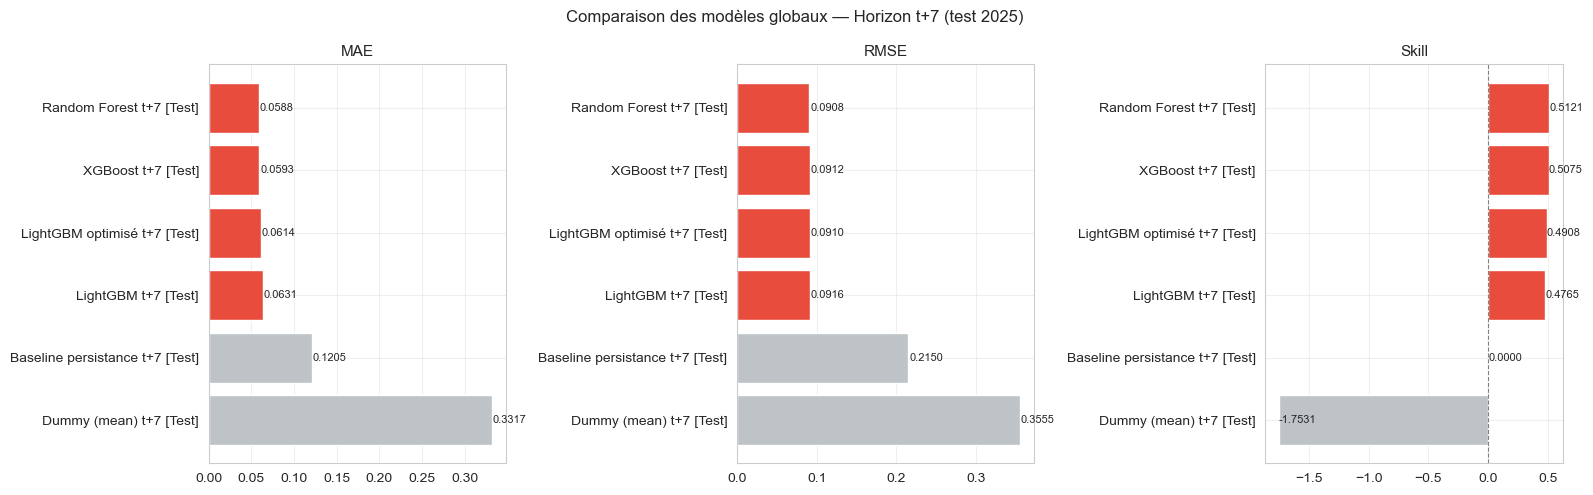

In [10]:
df_res = pd.DataFrame(RESULTS)
df_test = (df_res[df_res['Split'] == 'Test']
           .drop(columns='Split')
           .sort_values('MAE')
           .reset_index(drop=True))

print('═' * 65)
print('  PERFORMANCES SUR LE JEU DE TEST 2025 — modèle global t+7')
print('═' * 65)
print(df_test[['Modele','MAE','RMSE','Skill']].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#e74c3c' if 'Baseline' not in m and 'Dummy' not in m else '#bdc3c7'
          for m in df_test['Modele']]
for ax, metric in zip(axes, ['MAE','RMSE','Skill']):
    bars = ax.barh(df_test['Modele'], df_test[metric], color=colors, edgecolor='white')
    for bar, val in zip(bars, df_test[metric]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
    ax.set_title(metric, fontsize=11); ax.invert_yaxis()
    if metric == 'Skill':
        ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
fig.suptitle(f'Comparaison des modèles globaux — Horizon t+{HORIZON} (test 2025)', fontsize=12)
plt.tight_layout(); plt.show()


## 10. Analyse des résidus — LightGBM optimisé

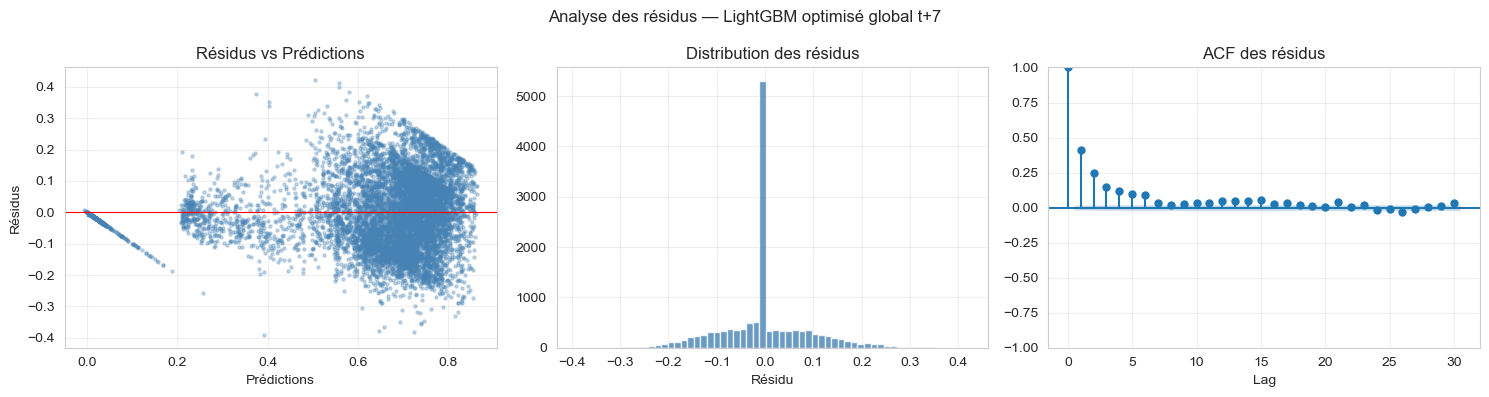

Résidu moyen  : -0.00207  (proche de 0 = pas de biais systématique)
Écart-type    : 0.0910
Skewness      : 0.252
% résidus < 0.05 : 56.2%


In [11]:
residus = y_te.values - pred_lgb_opt_test
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(pred_lgb_opt_test, residus, alpha=0.3, s=5, color='steelblue')
axes[0].axhline(0, color='red', linewidth=0.8)
axes[0].set_xlabel('Prédictions'); axes[0].set_ylabel('Résidus')
axes[0].set_title('Résidus vs Prédictions')

axes[1].hist(residus, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribution des résidus'); axes[1].set_xlabel('Résidu')

plot_acf(residus, lags=30, ax=axes[2], alpha=0.05)
axes[2].set_title('ACF des résidus'); axes[2].set_xlabel('Lag')

plt.suptitle(f'Analyse des résidus — LightGBM optimisé global t+{HORIZON}', fontsize=12)
plt.tight_layout(); plt.show()

print(f'Résidu moyen  : {residus.mean():.5f}  (proche de 0 = pas de biais systématique)')
print(f'Écart-type    : {residus.std():.4f}')
print(f'Skewness      : {skew(residus):.3f}')
print(f'% résidus < 0.05 : {(np.abs(residus) < 0.05).mean()*100:.1f}%')


## 11. Importance des variables — LightGBM optimisé

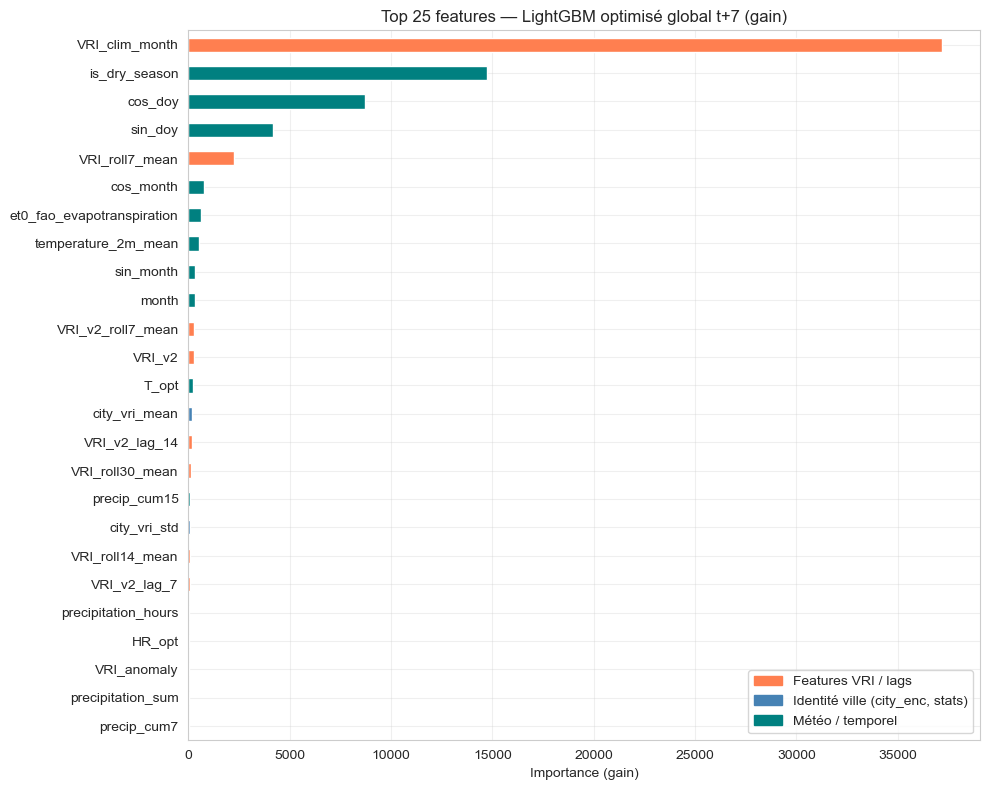

In [12]:
feat_imp = pd.Series(
    lgb_opt.booster_.feature_importance(importance_type='gain'),
    index=FEATURE_COLS
).sort_values(ascending=True).tail(25)

fig, ax = plt.subplots(figsize=(10, 8))
colors_imp = ['coral'     if 'VRI' in f else
              'steelblue' if f in ['city_enc','city_vri_mean','city_vri_std'] else
              'teal'      for f in feat_imp.index]
feat_imp.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
ax.set_title(f'Top 25 features — LightGBM optimisé global t+{HORIZON} (gain)', fontsize=12)
ax.set_xlabel('Importance (gain)')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='coral',     label='Features VRI / lags'),
    Patch(color='steelblue', label='Identité ville (city_enc, stats)'),
    Patch(color='teal',      label='Météo / temporel'),
], loc='lower right')
plt.tight_layout(); plt.show()


## 12. Performances par ville et région

Top 10 villes les mieux prédites :
      city       region      MAE     RMSE
    Maroua Extreme-Nord 0.045849 0.070696
    Guider         Nord 0.046189 0.070713
    Mokolo Extreme-Nord 0.046269 0.072138
Ngaoundere     Adamaoua 0.046354 0.070390
    Garoua         Nord 0.047749 0.070220
  Kousseri Extreme-Nord 0.048770 0.077668
    Tibati     Adamaoua 0.048994 0.071556
    Yagoua Extreme-Nord 0.049074 0.077075
   Touboro         Nord 0.049836 0.073594
      Poli         Nord 0.050711 0.075350

Top 10 villes les moins bien prédites :
      city    region      MAE     RMSE
      Loum  Littoral 0.069239 0.100093
   Bertoua       Est 0.069347 0.098407
Sangmelima       Sud 0.069432 0.099212
      Edea  Littoral 0.070087 0.099120
   Dschang     Ouest 0.071617 0.109071
     Kumba Sud-Ouest 0.072254 0.108925
     Limbe Sud-Ouest 0.072779 0.104886
   Batouri       Est 0.074097 0.104370
     Kribi       Sud 0.074123 0.108885
     Bafia    Centre 0.075854 0.108832

MAE moyen par région :
region
Ex

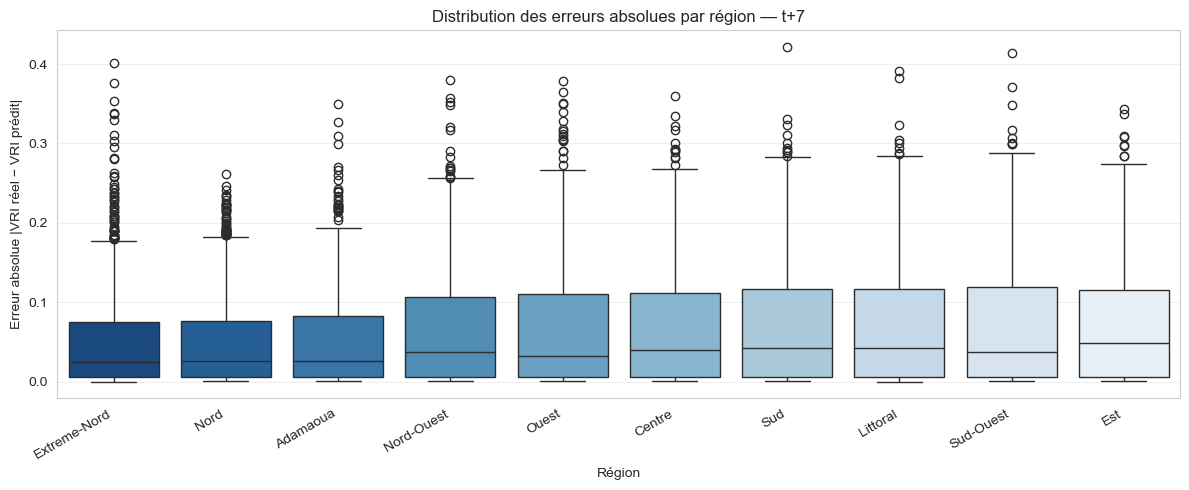

In [13]:
perf_ville = te[['city','region']].copy()
perf_ville['y_true'] = y_te.values
perf_ville['y_pred'] = pred_lgb_opt_test

city_perf = (
    perf_ville.groupby(['city','region'])
    .apply(lambda g: pd.Series({
        'MAE' : mean_absolute_error(g['y_true'], g['y_pred']),
        'RMSE': rmse(g['y_true'], g['y_pred']),
        'N'   : len(g)
    }), include_groups=False)
    .reset_index().sort_values('MAE')
)

print('Top 10 villes les mieux prédites :')
print(city_perf.head(10)[['city','region','MAE','RMSE']].to_string(index=False))
print()
print('Top 10 villes les moins bien prédites :')
print(city_perf.tail(10)[['city','region','MAE','RMSE']].to_string(index=False))
print()
print('MAE moyen par région :')
print(city_perf.groupby('region')['MAE'].mean().sort_values().round(4).to_string())

# Boxplot MAE par région
fig, ax = plt.subplots(figsize=(12, 5))
region_order = city_perf.groupby('region')['MAE'].mean().sort_values().index
city_perf_plot = perf_ville.copy()
city_perf_plot['MAE_abs'] = np.abs(city_perf_plot['y_true'] - city_perf_plot['y_pred'])
sns.boxplot(data=city_perf_plot, x='region', y='MAE_abs', order=region_order, ax=ax,
            palette='Blues_r')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_title(f'Distribution des erreurs absolues par région — t+{HORIZON}', fontsize=12)
ax.set_xlabel('Région'); ax.set_ylabel('Erreur absolue |VRI réel − VRI prédit|')
plt.tight_layout(); plt.show()


## 13. Prédictions vs réalité — villes de référence

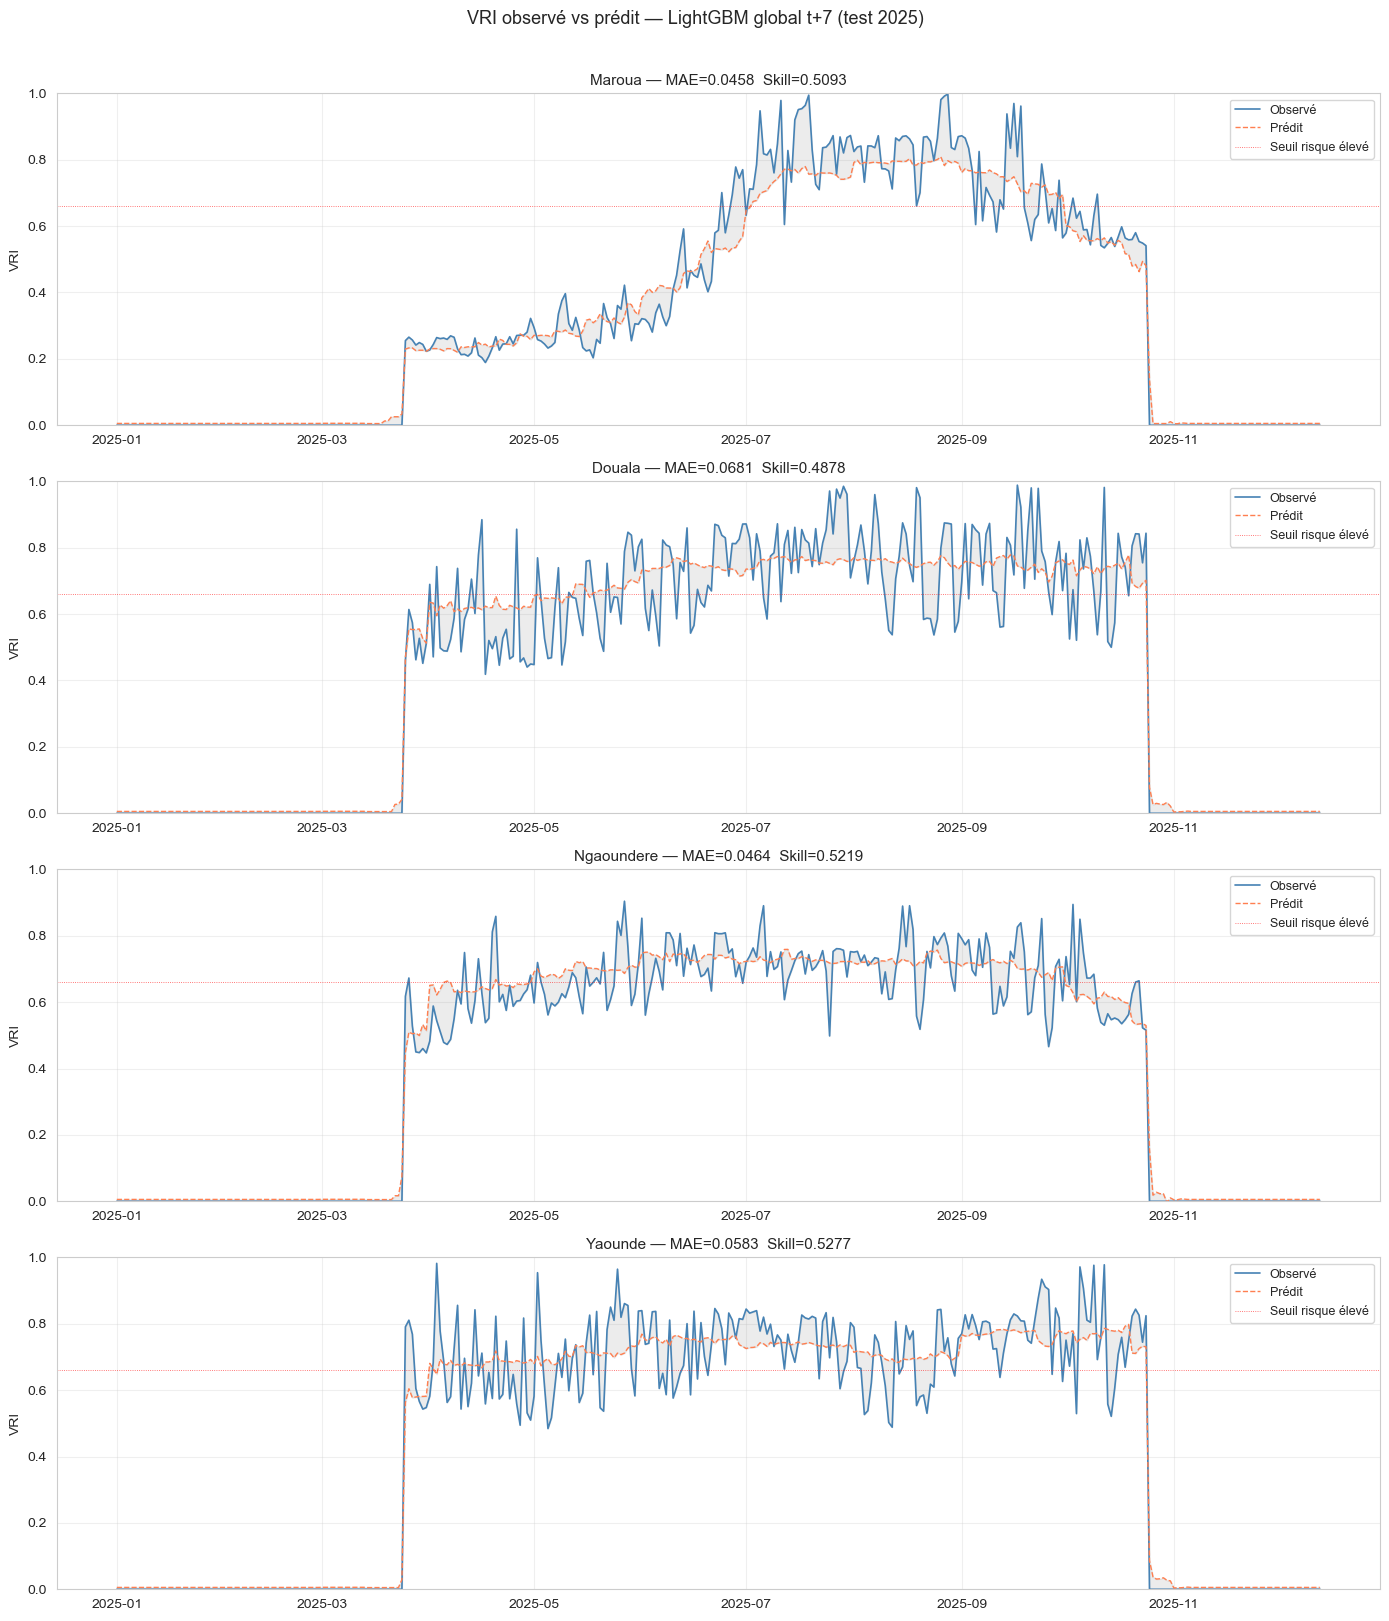

In [14]:
fig, axes = plt.subplots(len(villes_ref), 1,
                          figsize=(14, 4*len(villes_ref)), sharex=False)
if len(villes_ref) == 1: axes = [axes]

for ax, ville in zip(axes, villes_ref):
    mask  = te['city'] == ville
    if mask.sum() == 0: continue
    dates = te.loc[mask, 'time']
    y_v   = y_te.values[mask.values]
    p_v   = pred_lgb_opt_test[mask.values]
    mae_v = mean_absolute_error(y_v, p_v)
    ss_v  = skill_score(y_v, p_v, X_te.loc[mask.values, 'VRI_lag_7'].values)
    ax.plot(dates, y_v, label='Observé', color='steelblue', linewidth=1.2)
    ax.plot(dates, p_v, label='Prédit',  color='coral',     linewidth=1.0, linestyle='--')
    ax.fill_between(dates, y_v, p_v, alpha=0.15, color='gray')
    ax.axhline(SEUIL_ELEVE, color='red', linewidth=0.6, linestyle=':', alpha=0.7, label='Seuil risque élevé')
    ax.set_title(f'{ville} — MAE={mae_v:.4f}  Skill={ss_v:.4f}', fontsize=11)
    ax.set_ylabel('VRI'); ax.set_ylim(0, 1); ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.suptitle(f'VRI observé vs prédit — LightGBM global t+{HORIZON} (test 2025)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## 14. Classification du risque vectoriel
Les prédictions continues sont converties en classes :
- **Faible** : VRI ∈ [0, 0.33]
- **Moyen** : VRI ∈ ]0.33, 0.66]
- **Élevé** : VRI ∈ ]0.66, 1]


Rapport de classification (classes de risque VRI) :
              precision    recall  f1-score   support

      Faible       0.99      0.98      0.99      5736
       Moyen       0.68      0.50      0.58      3371
       Eleve       0.71      0.86      0.78      4766

    accuracy                           0.82     13873
   macro avg       0.80      0.78      0.78     13873
weighted avg       0.82      0.82      0.82     13873



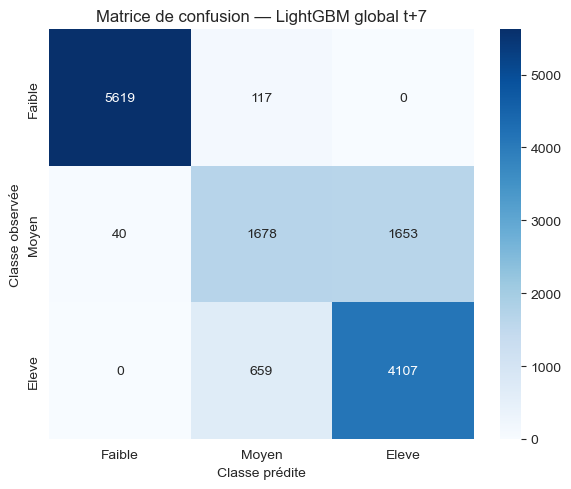

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

bins   = [-0.001, 0.33, 0.66, 1.001]
labels = ['Faible', 'Moyen', 'Eleve']

te_out = te[['time','city','region']].copy()
te_out['VRI_observe'] = y_te.values
te_out['VRI_predit']  = pred_lgb_opt_test

te_out['classe_observee'] = pd.cut(te_out['VRI_observe'], bins=bins, labels=labels).astype(str)
te_out['classe_predite']  = pd.cut(te_out['VRI_predit'],  bins=bins, labels=labels).astype(str)
te_out = te_out[
    (te_out['classe_observee'] != 'nan') &
    (te_out['classe_predite']  != 'nan')
].reset_index(drop=True)

print('Rapport de classification (classes de risque VRI) :')
print(classification_report(te_out['classe_observee'], te_out['classe_predite'],
                              labels=labels, target_names=labels, zero_division=0))

cm = confusion_matrix(te_out['classe_observee'], te_out['classe_predite'], labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel('Classe prédite'); ax.set_ylabel('Classe observée')
ax.set_title(f'Matrice de confusion — LightGBM global t+{HORIZON}')
plt.tight_layout(); plt.show()


## 15. Courbes ROC — Détection risque élevé (VRI ≥ 0.66)

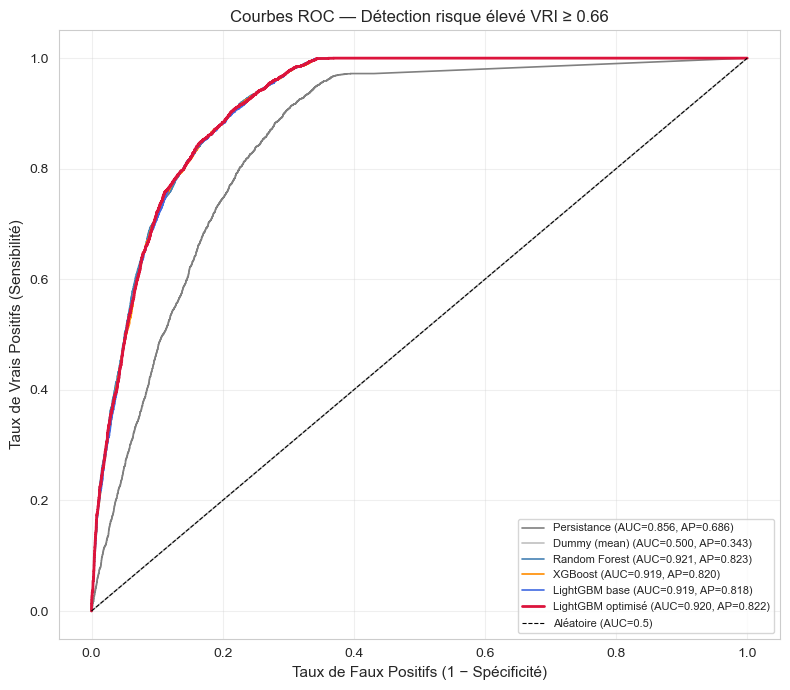


── AUC et Average Precision ──────────────────────────────
  Persistance               AUC=0.8561  AP=0.6862
  Dummy (mean)              AUC=0.5000  AP=0.3434
  Random Forest             AUC=0.9206  AP=0.8226
  XGBoost                   AUC=0.9195  AP=0.8196
  LightGBM base             AUC=0.9190  AP=0.8184
  LightGBM optimisé         AUC=0.9201  AP=0.8222


In [16]:
from sklearn.metrics import roc_curve, roc_auc_score, average_precision_score

y_te_bin = (y_te.values >= SEUIL_ELEVE).astype(int)

models_scores = {
    'Persistance'       : naive_test,
    'Dummy (mean)'      : pred_dummy_test,
    'Random Forest'     : pred_rf_test,
    'XGBoost'           : pred_xgb_test,
    'LightGBM base'     : pred_lgb_test,
    'LightGBM optimisé' : pred_lgb_opt_test,
}

fig, ax = plt.subplots(figsize=(8, 7))
colors_roc = ['gray','silver','steelblue','darkorange','royalblue','crimson']

for (name, scores), color in zip(models_scores.items(), colors_roc):
    scores_c = np.clip(scores, 0, 1)
    fpr, tpr, _ = roc_curve(y_te_bin, scores_c)
    auc = roc_auc_score(y_te_bin, scores_c)
    ap  = average_precision_score(y_te_bin, scores_c)
    lw  = 2.0 if 'optimisé' in name else 1.2
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f}, AP={ap:.3f})',
            color=color, linewidth=lw)

ax.plot([0,1],[0,1], 'k--', linewidth=0.8, label='Aléatoire (AUC=0.5)')
ax.set_xlabel('Taux de Faux Positifs (1 − Spécificité)', fontsize=11)
ax.set_ylabel('Taux de Vrais Positifs (Sensibilité)', fontsize=11)
ax.set_title(f'Courbes ROC — Détection risque élevé VRI ≥ {SEUIL_ELEVE}', fontsize=12)
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()

print('\n── AUC et Average Precision ──────────────────────────────')
for name, scores in models_scores.items():
    scores_c = np.clip(scores, 0, 1)
    auc = roc_auc_score(y_te_bin, scores_c)
    ap  = average_precision_score(y_te_bin, scores_c)
    print(f'  {name:<25} AUC={auc:.4f}  AP={ap:.4f}')


## 16. Export du modèle final
Le modèle LightGBM optimisé global est exporté en 3 formats :
- **joblib** : recommandé pour sklearn/LightGBM
- **pickle** : format standard Python
- **natif LightGBM (.txt)** : interopérable avec d'autres langages


In [17]:
from datetime import datetime

os.makedirs('../models', exist_ok=True)

# ── joblib (recommandé) ──
joblib.dump(lgb_opt,      '../models/lgb_global_t7.pkl')
joblib.dump(FEATURE_COLS, '../models/feature_cols.pkl')

# ── pickle ──
with open('../models/lgb_global_t7_pickle.pkl', 'wb') as f:
    pickle.dump(lgb_opt, f, protocol=4)

# ── Format natif LightGBM ──
lgb_opt.booster_.save_model('../models/lgb_global_t7.txt')

# ── Métriques de référence ──
mae_val  = float(mean_absolute_error(y_val, pred_lgb_opt_val))
mae_test = float(mean_absolute_error(y_te,  pred_lgb_opt_test))
rmse_val  = float(rmse(y_val, pred_lgb_opt_val))
rmse_test = float(rmse(y_te,  pred_lgb_opt_test))
skill_val  = float(skill_score(y_val, pred_lgb_opt_val,  naive_val))
skill_test = float(skill_score(y_te,  pred_lgb_opt_test, naive_test))

# ── Métadonnées JSON ──
metadata = {
    'exported_at'    : datetime.now().isoformat(timespec='seconds'),
    'model_type'     : 'LightGBMRegressor — global (toutes villes)',
    'horizon'        : f't+{HORIZON} jours',
    'n_villes'       : int(df_feat['city'].nunique()),
    'villes'         : sorted(df_feat['city'].unique().tolist()),
    'train_period'   : f'{tr["time"].min().date()} → {tr["time"].max().date()}',
    'val_period'     : f'{v["time"].min().date()} → {v["time"].max().date()}',
    'test_period'    : f'{te["time"].min().date()} → {te["time"].max().date()}',
    'n_train'        : int(len(X_tr)),
    'n_val'          : int(len(X_val)),
    'n_test'         : int(len(X_te)),
    'n_features'     : len(FEATURE_COLS),
    'feature_names'  : FEATURE_COLS,
    'best_params'    : best_params,
    'val_metrics'    : {'MAE': round(mae_val,4),  'RMSE': round(rmse_val,4),  'Skill': round(skill_val,4)},
    'test_metrics'   : {'MAE': round(mae_test,4), 'RMSE': round(rmse_test,4), 'Skill': round(skill_test,4)},
    'files': {
        'model_joblib' : '../models/lgb_global_t7.pkl',
        'model_pickle' : '../models/lgb_global_t7_pickle.pkl',
        'model_native' : '../models/lgb_global_t7.txt',
        'feature_cols' : '../models/feature_cols.pkl',
        'metadata'     : '../models/lgb_global_t7_metadata.json',
    }
}
with open('../models/lgb_global_t7_metadata.json', 'w', encoding='utf-8') as f:
    _json.dump(metadata, f, indent=2, ensure_ascii=False)

# ── Métriques par ville → CSV ──
perf_export = te[['city','region']].copy()
perf_export['y_true'] = y_te.values
perf_export['y_pred'] = pred_lgb_opt_test
city_metrics = (
    perf_export.groupby(['city','region'])
    .apply(lambda g: pd.Series({
        'MAE' : round(mean_absolute_error(g['y_true'], g['y_pred']), 4),
        'RMSE': round(rmse(g['y_true'], g['y_pred']), 4),
        'N'   : len(g)
    }), include_groups=False)
    .reset_index().sort_values('MAE')
)
city_metrics.to_csv('../models/metrics_par_ville.csv', index=False)

print('═' * 60)
print('  Modèle global exporté avec succès')
print('═' * 60)
print('  • ../models/lgb_global_t7.pkl          (joblib)')
print('  • ../models/lgb_global_t7_pickle.pkl   (pickle)')
print('  • ../models/lgb_global_t7.txt          (natif LightGBM)')
print('  • ../models/feature_cols.pkl')
print('  • ../models/lgb_global_t7_metadata.json')
print('  • ../models/metrics_par_ville.csv')
print()
print(f'  Val  → MAE={round(mae_val,4)}  RMSE={round(rmse_val,4)}  Skill={round(skill_val,4)}')
print(f'  Test → MAE={round(mae_test,4)}  RMSE={round(rmse_test,4)}  Skill={round(skill_test,4)}')
print(f'  Villes couvertes : {int(df_feat["city"].nunique())} / 42')


════════════════════════════════════════════════════════════
  Modèle global exporté avec succès
════════════════════════════════════════════════════════════
  • ../models/lgb_global_t7.pkl          (joblib)
  • ../models/lgb_global_t7_pickle.pkl   (pickle)
  • ../models/lgb_global_t7.txt          (natif LightGBM)
  • ../models/feature_cols.pkl
  • ../models/lgb_global_t7_metadata.json
  • ../models/metrics_par_ville.csv

  Val  → MAE=0.0632  RMSE=0.0973  Skill=0.4634
  Test → MAE=0.0614  RMSE=0.091  Skill=0.4908
  Villes couvertes : 40 / 42


## 17. Vérification du rechargement

In [18]:
# Rechargement joblib
model_reloaded = joblib.load('../models/lgb_global_t7.pkl')
feats_reloaded = joblib.load('../models/feature_cols.pkl')

# Vérification reproductibilité
pred_check = model_reloaded.predict(X_te[feats_reloaded])
assert np.allclose(pred_check, pred_lgb_opt_test, atol=1e-6), \
    'ERREUR : prédictions divergentes après rechargement !'

print(f'Modèle rechargé  : {type(model_reloaded).__name__}')
print(f'Features         : {len(feats_reloaded)} colonnes')
print('Reproductibilité : OK ✓ — prédictions identiques')

# Rechargement métadonnées
with open('../models/lgb_global_t7_metadata.json', encoding='utf-8') as f:
    meta = _json.load(f)
print(f'Exporté le       : {meta["exported_at"]}')
print(f'Horizon          : {meta["horizon"]}')
print(f'Villes           : {meta["n_villes"]} villes')
print(f'Best params      : {meta["best_params"]}')

# Fonction predict production-ready
def predict_vri(model, X: pd.DataFrame, feature_cols: list,
                clip: bool = True) -> np.ndarray:
    """
    Wrapper de prédiction production-ready.
    Paramètres : model, X (DataFrame), feature_cols, clip=[0,1]
    Retourne   : np.ndarray de prédictions VRI dans [0,1]
    """
    missing = set(feature_cols) - set(X.columns)
    if missing:
        raise ValueError(f'Features manquantes : {missing}')
    preds = model.predict(X[feature_cols])
    return np.clip(preds, 0, 1) if clip else preds

# Test
preds_demo = predict_vri(model_reloaded, X_te, feats_reloaded)
print(f'\npredict_vri OK — {len(preds_demo)} prédictions')
print(f'Range : [{preds_demo.min():.4f}, {preds_demo.max():.4f}]')


Modèle rechargé  : LGBMRegressor
Features         : 32 colonnes
Reproductibilité : OK ✓ — prédictions identiques
Exporté le       : 2026-04-07T03:15:36
Horizon          : t+7 jours
Villes           : 40 villes
Best params      : {'learning_rate': 0.05, 'min_child_samples': 30, 'num_leaves': 31}

predict_vri OK — 13880 prédictions
Range : [0.0000, 0.8634]
